In [ ]:
pip install deap


Evaluating Environment: CartPole-v1
--- Running Seed 1/3 ---
  > Best Fitness Achieved: 500.00
--- Running Seed 2/3 ---
  > Best Fitness Achieved: 500.00
--- Running Seed 3/3 ---
  > Best Fitness Achieved: 500.00

Evaluating Environment: Acrobot-v1
--- Running Seed 1/3 ---
  > Best Fitness Achieved: -61.00
--- Running Seed 2/3 ---
  > Best Fitness Achieved: -63.00
--- Running Seed 3/3 ---
  > Best Fitness Achieved: -62.00


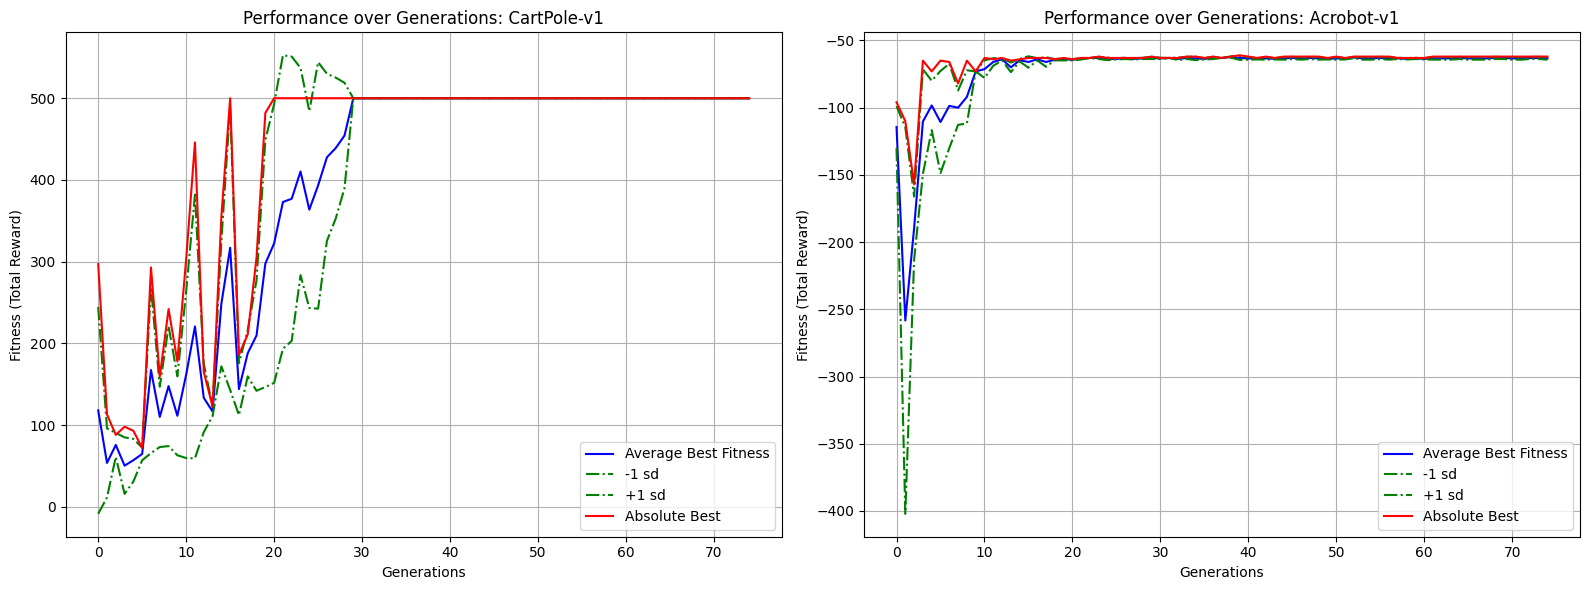

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from deap import algorithms, creator, base, cma, tools
import warnings

warnings.filterwarnings("ignore")

class NeuralNetwork:
    def __init__(self, layer_sizes, activations):
        self.layer_sizes = layer_sizes
        self.layers = None

        if isinstance(activations, list):
            if len(list(activations)) != len(layer_sizes) - 1:
                raise AttributeError("Number of activations does not match number of layers")
            self.activations = list(activations)
        else:
            self.activations = [activations] * (len(layer_sizes) - 1)

        self.vectorized_net = None

    def vectorized_size(self):
        return sum(map(lambda x: (x[0] + 1) * x[1], zip(self.layer_sizes, self.layer_sizes[1:])))

    def set_weights(self, vectorized_net):
        if len(vectorized_net) != self.vectorized_size():
            raise AttributeError(
                f"Length of vector does not match vectorized_size: {len(vectorized_net)} != {self.vectorized_size()}")

        self.vectorized_net = vectorized_net
        self.layers = []
        sum_sizes = 0
        for (p, n) in zip(self.layer_sizes, self.layer_sizes[1:]):
            layer = vectorized_net[sum_sizes: sum_sizes + (p + 1) * n]
            self.layers.append(np.reshape(layer, newshape=(p + 1, n)))
            sum_sizes += (p + 1) * n

    def eval_network(self, inputs):
        activations = inputs
        try:
            for act_func, layer in zip(self.activations, self.layers):
                activations_1 = np.append(np.array([1.0]), activations)
                activations = act_func(np.dot(activations_1, layer))
        except Exception as e:
            print("Activations:", activations)
            raise e
        return activations

def relu(x):
    return np.maximum(0, x)

def linear(x):
    return x

def fitness(ind, env_name, seed):
    net.set_weights(ind)
    env = gym.make(env_name)
    state, _ = env.reset(seed=seed)

    acc_reward = 0
    done = False
    truncated = False

    while not (done or truncated):
        action = np.argmax(net.eval_network(state))
        state, reward, done, truncated, _ = env.step(action)
        acc_reward += reward

    env.close()
    return acc_reward,

def plot_multi_seed_stats(all_seed_histories, env_name, ax):
    generation = range(len(all_seed_histories[0]))

    avg_fitness = np.mean(all_seed_histories, axis=0)
    stdev_fitness = np.std(all_seed_histories, axis=0)
    best_overall = np.max(all_seed_histories, axis=0)

    ax.plot(generation, avg_fitness, 'b-', label="Average Best Fitness")
    ax.plot(generation, avg_fitness - stdev_fitness, 'g-.', label="-1 sd")
    ax.plot(generation, avg_fitness + stdev_fitness, 'g-.', label="+1 sd")
    ax.plot(generation, best_overall, 'r-', label="Absolute Best")

    ax.set_title(f"Performance over Generations: {env_name}")
    ax.set_xlabel("Generations")
    ax.set_ylabel("Fitness (Total Reward)")
    ax.grid()
    ax.legend(loc="best")

if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

if __name__ == "__main__":
    environments = ['CartPole-v1', 'Acrobot-v1']
    num_seeds = 3
    ngen = 75

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for idx, env_name in enumerate(environments):
        print(f"\n{'='*50}\nEvaluating Environment: {env_name}\n{'='*50}")

        temp_env = gym.make(env_name)
        obs_dim = temp_env.observation_space.shape[0]
        act_dim = temp_env.action_space.n
        temp_env.close()

        global net
        net = NeuralNetwork([obs_dim, 16, act_dim], [relu, linear])
        ind_size = net.vectorized_size()

        all_seed_histories = []

        for seed in range(num_seeds):
            print(f"--- Running Seed {seed + 1}/{num_seeds} ---")
            np.random.seed(seed)

            toolbox = base.Toolbox()
            toolbox.register("evaluate", fitness, env_name=env_name, seed=seed)

            strategy = cma.Strategy(centroid=[0.0]*ind_size, sigma=0.1, lambda_=50)
            toolbox.register("generate", strategy.generate, creator.Individual)
            toolbox.register("update", strategy.update)

            hof = tools.HallOfFame(1)

            stats = tools.Statistics(lambda ind: ind.fitness.values)
            stats.register("avg", np.mean)
            stats.register("std", np.std)
            stats.register("min", np.min)
            stats.register("max", np.max)

            pop, logbook = algorithms.eaGenerateUpdate(
                toolbox, ngen=ngen, stats=stats, halloffame=hof, verbose=False
            )

            max_fitness_history = logbook.select("max")
            all_seed_histories.append(max_fitness_history)

            print(f"  > Best Fitness Achieved: {np.max(max_fitness_history):.2f}")

        plot_multi_seed_stats(all_seed_histories, env_name, axes[idx])

    plt.tight_layout()
    plt.show()

**1. List Of Environments I Tried**

To evaluate the neuroevolution algorithm, I selected two discrete environments from the Classic Control Group in `gymnasium` library

1) **CartPole-v1:** The objective is to keep a pole balanced on a moving cart

2) **Acrobot-v1:** The objective is to swing a two-link system up to a target height

**2. Description of the Algorithm and Setting**

This solution evolves the weight vector of a fixed network topology using the Covariance Matrix Adaptation Evolution Strategy. The implementation utilizes the neural network architecture and DEAP strategies provided in the lecture materials, adapted for dynamic reinforcement learning environments.
##

 **Neural Neywork Topology:** A custom feedforward network class that reshapes a 1D vector into weight and bias matrices.

- **Input Layer:** matches the observation of the environment

- **Hidden Layer:** 16 neurons with a `relu` activation function

- **Output Layer:** Matches the discrete action space using a linear activation function

**Evolutionat Strategy:** I managed this using `deep` library

* **Generations:** 75 (Based on lecture parameters)

* **Sigma:** 0.1.

* **Lambda:** 50. (In the lab formula of `5 * ind_size` created popilations over 800 individuals, which was hard for evaluating 500-step Gym environment. I manually adjusted this to 50 for RL efficiency. Before this the exectuion time was so slow and took so much time after adjustment it highly reduced)


**3. Instructions for Running the Code**

1) Ensure you have the required libraries:

`pip install gymnasium numpy matplotlib deap`

2) Run the python script above
3) The script will sequentially train on both libraries executing 3 random seeds for each
4) Once finished, it will automatically generate and display the final plot showing the performance of the ebst individuals over generations



